In [8]:
# CUSTOMER SEGMENTATION USING K-MEANS
# ==========================================

import os
import warnings


In [9]:
# Suppress common Windows/KMeans warnings
os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
# LOAD DATASET
# ==========================================

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())


Dataset Shape: (200, 5)

First 5 Records:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [12]:
# SELECT FEATURES
# ==========================================

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


In [13]:
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
# ELBOW METHOD
# ==========================================

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


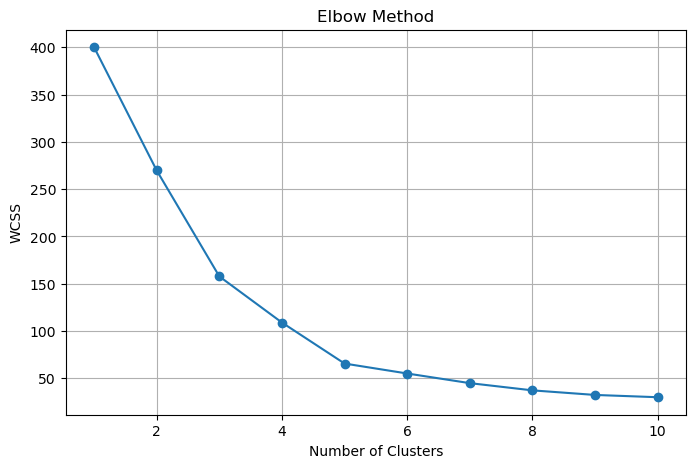

In [15]:
# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [16]:
# TRAIN FINAL K-MEANS MODEL
# ==========================================

kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)


In [17]:
# Add cluster labels
df['Cluster'] = clusters

In [18]:
# DISPLAY CLUSTERED DATA
# ==========================================

print("\nCluster Counts:")
print(df['Cluster'].value_counts())



Cluster Counts:
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


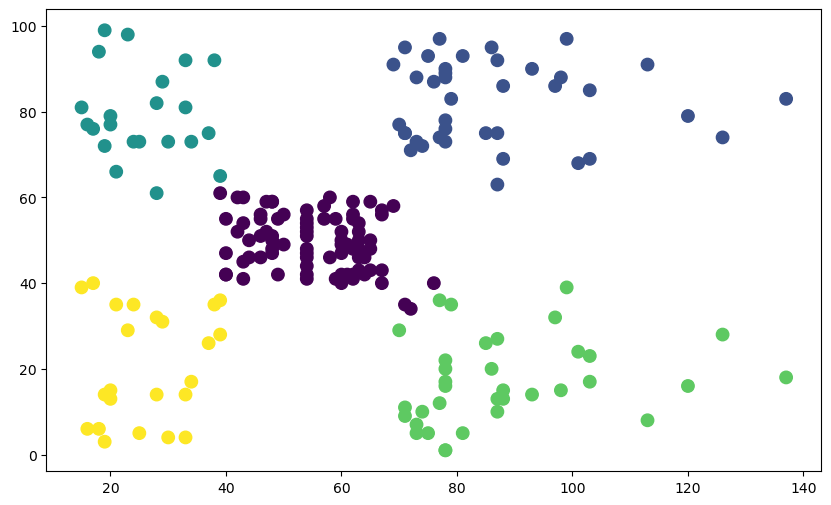

In [19]:
# VISUALIZE CLUSTERS
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    s=80
)

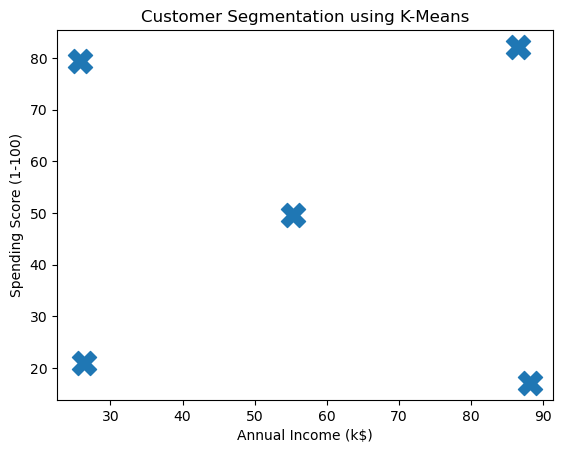

In [22]:

# Cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=300,
    marker='X'
)
plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [23]:
# SAVE OUTPUT
# ==========================================

df.to_csv("Customer_Segments.csv", index=False)

print("\nCustomer segmentation completed successfully.")
print("Output saved as Customer_Segments.csv")


Customer segmentation completed successfully.
Output saved as Customer_Segments.csv
